Узлов: 5514 Ребер: 12199
Расчет узлов
426923808 7.36


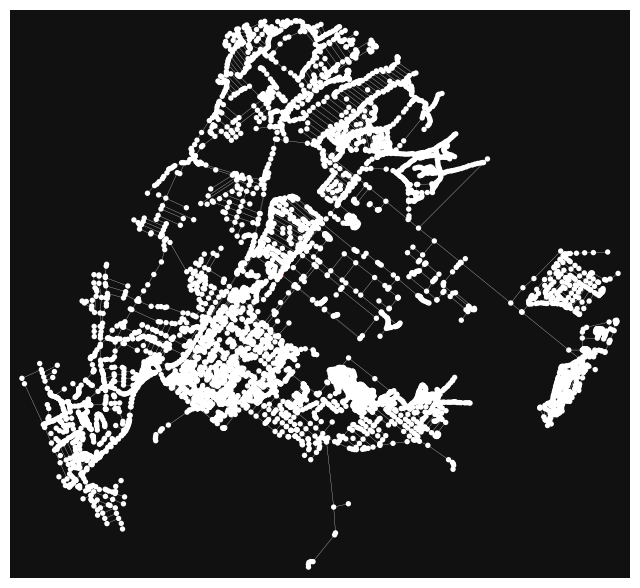

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import calc_node_metric
from genesis.swiss_knife import msfpl, ssfpl


G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

print('Расчет узлов')
best_node, best_val = Graphs.get_best_node_full(G, 
                          path_function=msfpl,
                          metric_function=np.mean
                          )
print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 5 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

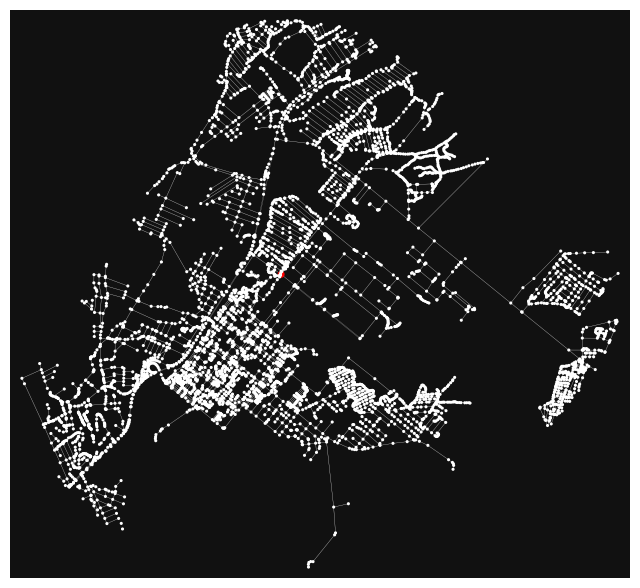

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [3]:
nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 5 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

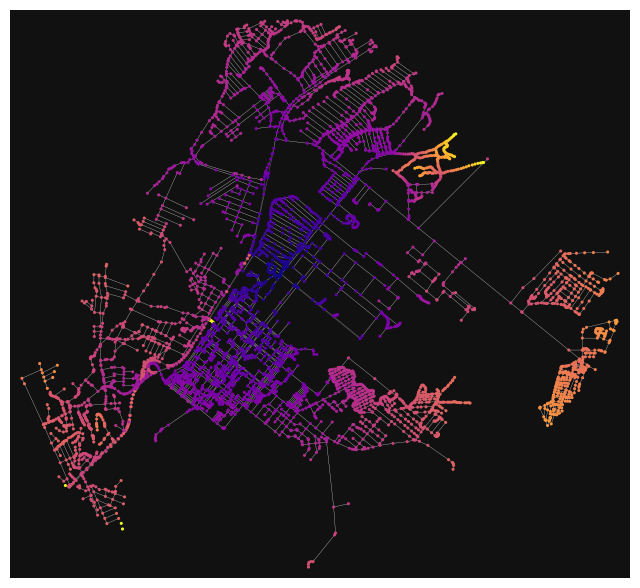

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [11]:
from genesis.swiss_knife import ssfpl
lens = ssfpl(G, best_node, weight = 'travel_time')
mval = max(lens.values())
lens_full = {node:lens[node] if node in lens else mval for node in G.nodes()}

nx.set_node_attributes(G, lens_full, 'route_time')
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=5)

In [20]:
# from genesis.metrics import 
nodes_mean = {}
nodes_max = {}

i=0
for node in G.nodes():
    print(f'{i}/{G.number_of_nodes():<5}', end='\r')
    nodes_mean[node] = calc_node_metric(G, 
                    node, 
                    path_function=msfpl, 
                    metric_function=np.mean)
    nodes_max[node] = calc_node_metric(G, 
                    node, 
                    path_function=msfpl, 
                    metric_function=np.max)
    i+=1

In [21]:
nx.set_node_attributes(G, nodes_mean, 'nodes_mean')
nx.set_node_attributes(G, nodes_max, 'nodes_max')

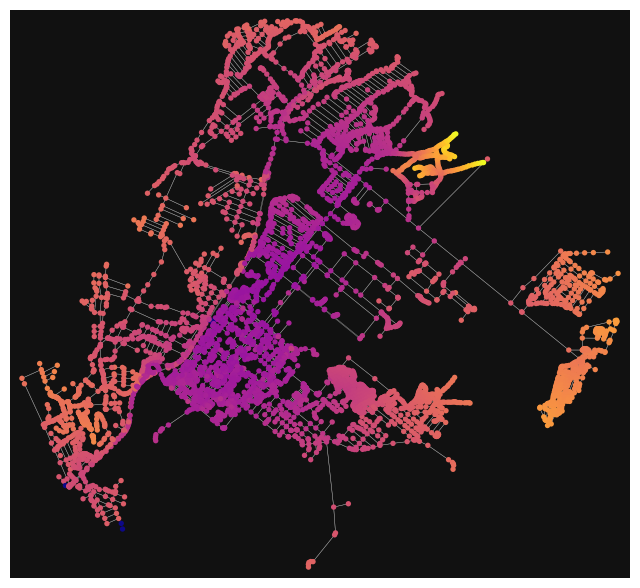

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [22]:
nc = ox.plot.get_node_colors_by_attr(G, attr="nodes_mean", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

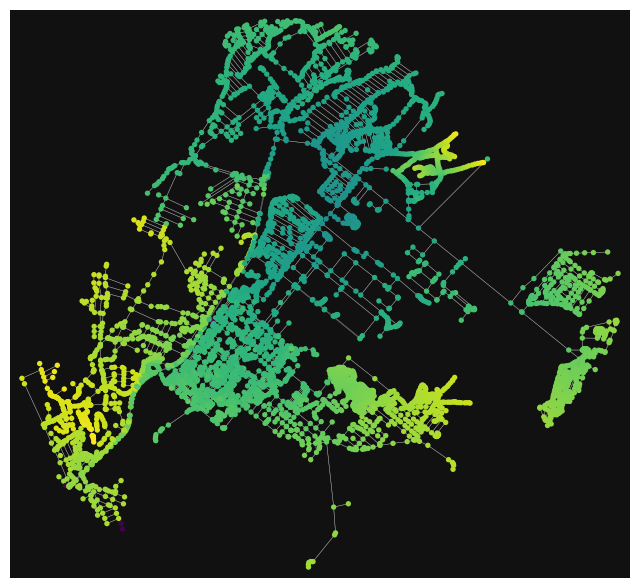

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [26]:
nc = ox.plot.get_node_colors_by_attr(G, attr="nodes_max", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Потом удалить!

{'E': <genesis.environments.CommonEnvironment object at 0x00000216C07CF050>, 'ssfpl': <function single_source_dijkstra_path_length at 0x00000216C314EA20>, 'msfpl': <function multi_source_dijkstra_path_length at 0x00000216C314EC00>, 'delay_time': 1}
name
ОП ПСЧ-1    4116050007
ПСЧ-1       1545611759
Name: node, dtype: int64
2 5504 5514


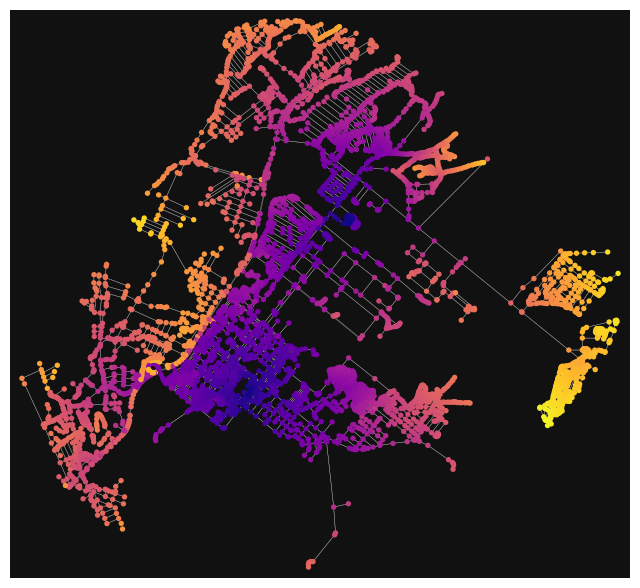

In [2]:
from genesis.models import Environment, Computer
from genesis.features import RoadNetworkGraph, SpeedProfile, DislocationProfile
from genesis.morphers import MorphersGraph, MorphersSpatialFeature
import networkx as nx
import osmnx as ox

from genesis.environments import CommonEnvironment

class TestComputer(Computer):

    def execute(self):
        G = self.E.RNG.G
        MorphersGraph.add_edge_travel_times(G, self.E.SP)
        # gdf_e = ox.graph_to_gdfs(self.E.RNG.G, nodes=False)
        # print(gdf_e.columns)
        MorphersSpatialFeature.add_nearest_node(self.E.DP, self.E.RNG)
        nl = self.E.DP.data['node']
        print(nl)
        lens = self.msfpl(G, list(nl), weight='travel_time')
        lens_full = {node:lens[node] if node in lens else 11 for node in G.nodes()}
        # lens = {k: v if k in nl else 1000 for k,v in lens.items()}
        print(len(nl), len(lens), len(lens_full))
        nx.set_node_attributes(G, lens_full, 'arrival_time')

        nc = ox.plot.get_node_colors_by_attr(G, attr="arrival_time", cmap="plasma")
        ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

        return super().execute()


# Создание классом
E = CommonEnvironment(path='tests/data/')
E.RNG.path = 'test_rng.ml'      # Тест загрузки ГДС из иной папки
E.load()
E.crs = E.RNG.crs


# # Создание конструктором:
# E = Environment(path='tests/data/')
# E.add_features(
#     [
#         RoadNetworkGraph(path='test_rng.ml'),
#         DislocationProfile(),
#         SpeedProfile()
#     ]
# ).load()
# E.crs = E.RNG.crs



C = TestComputer(E)
C.set_settings(
    ssfpl = nx.single_source_dijkstra_path_length,
    msfpl = nx.multi_source_dijkstra_path_length,
    delay_time = 1,
)


print(C.__dict__)

C.execute()

In [3]:
E.DP.data

,description,type,class,geometry
name,,,,
ОП ПСЧ-1,Тестовая ПСЧ,ФПС,ОП,POINT (93.36610 56.14129)
ПСЧ-1,Тестовая ПСЧ,ФПС,ПСЧ,POINT (93.33966 56.11563)


In [10]:
print(E.crs)
print(E.RNG.crs)
print(E.DP.crs)

epsg:4326
epsg:4326
epsg:4326


In [11]:
E.crs = 'epsg:3857'
print(E.crs)
print(E.RNG.crs)
print(E.DP.crs)

epsg:3857
epsg:4326
epsg:3857


# Расчет профиля прибытия

In [2]:
from genesis.models import Environment, Computer
from genesis.features import RoadNetworkGraph, SpeedProfile, DislocationProfile
from genesis.morphers import MorphersGraph, MorphersSpatialFeature
import networkx as nx
import osmnx as ox
from genesis.calculators import Arrivals

from genesis.environments import CommonEnvironment

class TestComputer(Computer):

    def execute(self):
        G = self.E.RNG.G
        MorphersGraph.add_edge_travel_times(G, self.E.SP)
        MorphersSpatialFeature.add_nearest_node(self.E.DP, self.E.RNG)
        self.df_out = Arrivals.calc_AP(self.E, path_function=self.msf)

        return super().execute()


# Создание классом
E = CommonEnvironment(path='tests/data/')
E.RNG.path = 'test_rng.ml'      # Загрузка ГДС из иной папки
E.load()
E.crs = E.RNG.crs

c:\Users\Obsidian\.conda\envs\ox2\lib\site-packages\osmnx\utils_graph.py:88: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  gdf_edges["geometry"] = np.nan


In [9]:
C = TestComputer(E)
C.set_settings(
    ssfpl = nx.single_source_dijkstra_path_length,
    msfpl = nx.multi_source_dijkstra_path_length,
    msf = nx.multi_source_dijkstra,
    delay_time = 1,
)
print(C.__dict__.keys())

dict_keys(['E', 'ssfpl', 'msfpl', 'msf', 'delay_time'])


In [10]:
C.execute()
C.df_out

,arrival_time,unit
4116050007,1.000000,ОП ПСЧ-1
1545611759,1.000000,ПСЧ-1
1545611804,1.027307,ПСЧ-1
4116050008,1.049884,ОП ПСЧ-1
1545611797,1.085096,ПСЧ-1
...,...,...
2042076354,15.749531,ОП ПСЧ-1
2042076417,15.794416,ОП ПСЧ-1
2042076383,15.860593,ОП ПСЧ-1
2042076385,15.888286,ОП ПСЧ-1


## Создание компьютера классом

In [8]:
from genesis.models import Environment, Computer
# from genesis.features import RoadNetworkGraph, SpeedProfile, DislocationProfile
from genesis.morphers import MorphersGraph, MorphersSpatialFeature
import networkx as nx
# import osmnx as ox
from genesis.calculators import Arrivals

from genesis.environments import CommonEnvironment


class TestComputer(Computer):


    _version='1'

    def __init__(self, E:Environment, **kwargs):
        self.set_settings(
            environment = E,
            path_function = nx.multi_source_dijkstra,
            AP_function = Arrivals.calc_AP,
            RNG_name = 'RNG',
            DP_name = 'DP',
            AP_name = 'AP',
            SP_name = 'SP',
            DP_node_field = 'node',
            result_field = 'arrival_time',
            result_unit_field = 'unit',
            weight = 'travel_time',
            delay_time = 1,
            cutoff = None,
        )

    def execute(self):
        # Получаем объект графа из  ГДС
        G = self.E[self.RNG_name].G
        # Добавляем ребрам ГДС время следования по ним
        MorphersGraph.add_edge_travel_times(G,
                                            self.E[self.SP_name])
        # Сопоставляем пожарные подразделения с ближайшими узлами ГДС
        MorphersSpatialFeature.add_nearest_node(self.E[self.DP_name],
                                                self.E[self.RNG_name],
                                                node_field=self.DP_node_field)
        # Собственно расчет ПП (!!!В данный момент только pd.DataFrame - потом переделать!)
        # self.AP = self.AP_function(AP_name=self.AP_name, **self.__dict__)
        AP = self.AP_function(**self.__dict__)
        self.E.add_spatial_feature(AP)

        return super().execute()
    
# Создание классом
E = CommonEnvironment(path='tests/data/')
E.RNG.path = 'test_rng.ml'      # Загрузка ГДС из иной папки
E.load()
E.crs = E.RNG.crs

# Создание компьютера
C = TestComputer(E)
C.execute()
# C.AP

E.AP

ERROR:fiona._env:Cannot find table Подразделения
c:\Users\Obsidian\.conda\envs\ox2\lib\site-packages\osmnx\utils_graph.py:88: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  gdf_edges["geometry"] = np.nan


In [9]:
C.__dict__

{'E': <genesis.environments.CommonEnvironment at 0x2b818975360>,
 'path_function': <function networkx.algorithms.shortest_paths.weighted.multi_source_dijkstra(G, sources, target=None, cutoff=None, weight='weight')>,
 'AP_function': <function genesis.calculators.Arrivals.calc_AP(E: genesis.models.Environment, path_function, AP_name: str, RNG_name: str = 'RNG', DP_name: str = 'DP', DP_node_field: str = 'node', result_field: str = 'arrival_time', result_unit_field: str = 'unit', weight: str = 'travel_time', delay_time=1.0, cutoff=None, **kwargs)>,
 'RNG_name': 'RNG',
 'DP_name': 'DP',
 'AP_name': 'AP',
 'SP_name': 'SP',
 'DP_node_field': 'node',
 'result_field': 'arrival_time',
 'result_unit_field': 'unit',
 'weight': 'travel_time',
 'delay_time': 1,
 'cutoff': None}

In [11]:
E.AP.data

,arrival_time,unit,geometry
node,,,
4116050007,1.000000,ОП ПСЧ-1,POINT (93.36583 56.14105)
1545611759,1.000000,ПСЧ-1,POINT (93.33945 56.11579)
1545611804,1.027307,ПСЧ-1,POINT (93.33933 56.11587)
4116050008,1.049884,ОП ПСЧ-1,POINT (93.36612 56.14096)
1545611797,1.085096,ПСЧ-1,POINT (93.33909 56.11554)
...,...,...,...
2042076354,15.749531,ОП ПСЧ-1,POINT (93.41845 56.11089)
2042076417,15.794416,ОП ПСЧ-1,POINT (93.41745 56.11216)
2042076383,15.860593,ОП ПСЧ-1,POINT (93.41810 56.11166)


In [13]:
len(E.AP['ОП ПСЧ-1'])

2566

In [14]:
C.E.AP['ОП ПСЧ-1']

,arrival_time,unit,geometry
node,,,
4116050007,1.000000,ОП ПСЧ-1,POINT (93.36583 56.14105)
4116050008,1.049884,ОП ПСЧ-1,POINT (93.36612 56.14096)
4116049998,1.088708,ОП ПСЧ-1,POINT (93.36595 56.14084)
4116049997,1.115518,ОП ПСЧ-1,POINT (93.36582 56.14078)
4116050006,1.134394,ОП ПСЧ-1,POINT (93.36530 56.14146)
...,...,...,...
2042076354,15.749531,ОП ПСЧ-1,POINT (93.41845 56.11089)
2042076417,15.794416,ОП ПСЧ-1,POINT (93.41745 56.11216)
2042076383,15.860593,ОП ПСЧ-1,POINT (93.41810 56.11166)


In [2]:
# Сохранение ПП для дальнейшего тестирования
# C.AP.data[:100].to_csv('tests/data/ap_df.csv')
E.AP.save('tests/data/')

In [10]:
C.AP.layer_name

'ПП'

# Тест алгоритмов Дейкстры

In [2]:
import osmnx as ox

G = ox.load_graphml('tests/data/test_rng.ml')

gdf = ox.graph_to_gdfs(G)

In [5]:
gdf[0].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich